In [1]:
import re
import pandas as pd
import numpy as np

import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC   
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

pd.set_option("display.max_colwidth", 150)

In [3]:
nltk.download("punkt")
nltk.download("punkt_tab")
nltk.download("stopwords")
nltk.download("wordnet")
nltk.download("omw-1.4")

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\owner\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping tokenizers\punkt.zip.
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\owner\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping tokenizers\punkt_tab.zip.
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\owner\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping corpora\stopwords.zip.
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\owner\AppData\Roaming\nltk_data...
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\owner\AppData\Roaming\nltk_data...


True

In [4]:
df = pd.read_csv("IMDB Dataset.csv")
print(f"Rows: {df.shape[0]}")
print("Sentiment distribution: ")
print(df["sentiment"].value_counts())
df.head()

Rows: 50000
Sentiment distribution: 
sentiment
positive    25000
negative    25000
Name: count, dtype: int64


,review,sentiment
0,"One of the other reviewers has mentioned that after watching just 1 Oz episode you'll be hooked. They are right, as this is exactly what happened ...",positive
1,"A wonderful little production. <br /><br />The filming technique is very unassuming- very old-time-BBC fashion and gives a comforting, and sometim...",positive
2,"I thought this was a wonderful way to spend time on a too hot summer weekend, sitting in the air conditioned theater and watching a light-hearted ...",positive
3,Basically there's a family where a little boy (Jake) thinks there's a zombie in his closet & his parents are fighting all the time.<br /><br />Thi...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is a visually stunning film to watch. Mr. Mattei offers us a vivid portrait about human relations. Thi...",positive


In [5]:
n_with_html = df["review"].str.contains(r"<br\s*/?>").sum()
print(f"Reviews containing '<br /> HTML tags: {n_with_html} ({n_with_html/len(df)*100:.1f}%)")

Reviews containing '<br /> HTML tags: 29200 (58.4%)


In [6]:
stop_words = set(stopwords.words("english"))

negation_words = {
    "not", "no", "nor", "ain", "aren", "couldn", "didn", "doesn", "hadn",
    "hasn", "haven", "isn", "mightn", "mustn", "needn", "shan", "shouldn",
    "wasn", "weren", "won", "wouldn",
}
stop_words = stop_words - negation_words
lemmatizer = WordNetLemmatizer()


def clean_text(text):
    """Strip HTML tags, lowercase, remove punctuation (except apostrophes)
    and digits. Apostrophes are preserved so contractions tokenize correctly."""
    text = re.sub(r"<.*?>", " ", text)          # strip HTML tags like <br />
    text = text.lower()
    text = re.sub(r"[^a-z\s']", " ", text)       # keep letters and apostrophes
    text = re.sub(r"\s+", " ", text).strip()     # collapse extra whitespace
    return text


def preprocess(text):
    """Full pipeline: clean -> tokenize -> remove stop words -> lemmatize."""
    cleaned = clean_text(text)
    tokens = word_tokenize(cleaned)
    tokens = [t for t in tokens if t not in stop_words and len(t) > 1]
    tokens = [lemmatizer.lemmatize(t) for t in tokens]
    return " ".join(tokens)

In [7]:
example = df["review"].iloc[0]
print("BEFORE:", example[:200], "...")
print()
print("AFTER: ", preprocess(example)[:200], "...")

BEFORE: One of the other reviewers has mentioned that after watching just 1 Oz episode you'll be hooked. They are right, as this is exactly what happened with me.<br /><br />The first thing that struck me abo ...

AFTER:  one reviewer mentioned watching oz episode 'll hooked right exactly happened first thing struck oz brutality unflinching scene violence set right word go trust not show faint hearted timid show pull n ...


In [8]:
negation_test = "The movie wasn't good and I didn't enjoy it."
print("Negation test BEFORE:", negation_test)
print("Negation test AFTER: ", preprocess(negation_test))
print("(if this reads as positive words only, negation handling is broken)")

Negation test BEFORE: The movie wasn't good and I didn't enjoy it.
Negation test AFTER:  movie n't good n't enjoy
(if this reads as positive words only, negation handling is broken)


In [9]:
print("Applying pre-processing to all reviews (this takes a few minutes)...")
df["cleaned_review"] = df["review"].apply(preprocess)
print("Done.")

Applying pre-processing to all reviews (this takes a few minutes)...
Done.


In [10]:
y = (df["sentiment"] == "positive").astype(int)  # 1 = positive, 0 = negative

text_train, text_test, y_train, y_test = train_test_split(
    df["cleaned_review"], y, test_size=0.2, stratify=y, random_state=42
)

vectorizer = TfidfVectorizer(max_features=10000, ngram_range=(1, 2))
X_train = vectorizer.fit_transform(text_train)   # fit only on training text
X_test = vectorizer.transform(text_test)          # transform only, never fit

print(f"Train TF-IDF matrix: {X_train.shape}")
print(f"Test TF-IDF matrix:  {X_test.shape}")
print(f"Vocabulary size: {len(vectorizer.vocabulary_)}")

Train TF-IDF matrix: (40000, 10000)
Test TF-IDF matrix:  (10000, 10000)
Vocabulary size: 10000


In [11]:
print(f"Train: {X_train.shape[0]} reviews, Test: {X_test.shape[0]} reviews")

nb_model = MultinomialNB()
nb_model.fit(X_train, y_train)

svm_model = LinearSVC(random_state=42, max_iter=2000)
svm_model.fit(X_train, y_train)

print("Both models trained.")

Train: 40000 reviews, Test: 10000 reviews
Both models trained.


In [14]:
def evaluate(name, model, X_test, y_test):
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    print(f"--- {name} ---")
    print(f"Accuracy: {acc:.4f}")
    print(classification_report(y_test, y_pred, target_names=["Negative", "Positive"]))
    print("Confusion Matrix (rows=actual, cols=predicted):")
    print(confusion_matrix(y_test, y_pred))
    print()
    return acc


nb_acc = evaluate("Naive Bayes", nb_model, X_test, y_test)
svm_acc = evaluate("SVM (LinearSVC)", svm_model, X_test, y_test)

--- Naive Bayes ---
Accuracy: 0.8690
              precision    recall  f1-score   support

    Negative       0.88      0.85      0.87      5000
    Positive       0.86      0.89      0.87      5000

    accuracy                           0.87     10000
   macro avg       0.87      0.87      0.87     10000
weighted avg       0.87      0.87      0.87     10000

Confusion Matrix (rows=actual, cols=predicted):
[[4253  747]
 [ 563 4437]]

--- SVM (LinearSVC) ---
Accuracy: 0.8945
              precision    recall  f1-score   support

    Negative       0.90      0.89      0.89      5000
    Positive       0.89      0.90      0.89      5000

    accuracy                           0.89     10000
   macro avg       0.89      0.89      0.89     10000
weighted avg       0.89      0.89      0.89     10000

Confusion Matrix (rows=actual, cols=predicted):
[[4452  548]
 [ 507 4493]]



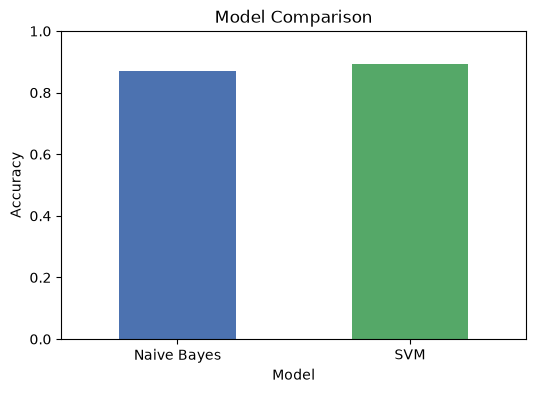

,Model,Accuracy
0,Naive Bayes,0.8690
1,SVM,0.8945


In [13]:
import matplotlib.pyplot as plt

comparison_df = pd.DataFrame({"Model": ["Naive Bayes", "SVM"], "Accuracy": [nb_acc, svm_acc]})
comparison_df.plot(x="Model", y="Accuracy", kind="bar", legend=False, figsize=(6, 4), color=["#4C72B0", "#55A868"])
plt.title("Model Comparison")
plt.ylabel("Accuracy")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.show()

comparison_df

In [15]:
new_reviews = [
    "This movie was absolutely wonderful, the acting was superb!",
    "Terrible film, a complete waste of time. I want my money back.",
    "It was okay, not great but not terrible either.",
]

for review in new_reviews:
    cleaned = preprocess(review)
    vec = vectorizer.transform([cleaned])
    nb_pred = "Positive" if nb_model.predict(vec)[0] == 1 else "Negative"
    svm_pred = "Positive" if svm_model.predict(vec)[0] == 1 else "Negative"
    print(f"Review: {review}")
    print(f"  Naive Bayes: {nb_pred} | SVM: {svm_pred}")
    print()

Review: This movie was absolutely wonderful, the acting was superb!
  Naive Bayes: Positive | SVM: Positive

Review: Terrible film, a complete waste of time. I want my money back.
  Naive Bayes: Negative | SVM: Negative

Review: It was okay, not great but not terrible either.
  Naive Bayes: Negative | SVM: Negative

